In [1]:


# This R environment comes with many helpful analytics packages installed
# It is defined by the kaggle/rstats Docker image: https://github.com/kaggle/docker-rstats
# For example, here's a helpful package to load

library(tidyverse) # metapackage of all tidyverse packages

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

list.files(path = "../input")

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session
R.home()
.libPaths()

install.packages("RSpectra")

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘tidyr’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


character(0)

[1] "/Library/Frameworks/R.framework/Resources"

[1] "/Library/Frameworks/R.framework/Versions/4.4-arm64/Resources/library"


The downloaded binary packages are in
	/var/folders/vg/v1ly5m3901d7m3db24gr9gfr0000gn/T//Rtmp4JfI4W/downloaded_packages


# Project 1 - Dimension Reduction

### 1.1 Data Loading 

In [2]:
# libraries
library(tidyverse)
# Install required packages (run once)
install.packages(c("infotheo", "randomForest", "caret", "pcalg", "graph", "RBGL"))


library(infotheo)   # MI estimation (for maxMIFS & DMIM)
library(ggplot2)
library(dplyr)
library(tidyr)
library(randomForest)
library(caret)



# Load and inspect the dataset
df <- read.csv("data/music_genre.csv")


str(df)
summary(df)

# Keep only Classical and Rap in a new data frame
df2 <- df %>% filter(music_genre %in% c("Classical", "Rap"))
df2$music_genre <- factor(df2$music_genre)

# Dimensions
dim(df2)

# Check if there are missing values
colSums(is.na(df2))

# Check the "?" instances visible in the dataset
sapply(df2, function(x) sum(x == "?", na.rm = TRUE))

# Class balance
table(df2$music_genre)


summary(df2)

# Identify non-numeric columns
sapply(df2, class)

Warning message:
“packages ‘graph’, ‘RBGL’ are not available for this version of R

Versions of these packages for your version of R might be available elsewhere,
see the ideas at
https://cran.r-project.org/doc/manuals/r-patched/R-admin.html#Installing-packages”



The downloaded binary packages are in
	/var/folders/vg/v1ly5m3901d7m3db24gr9gfr0000gn/T//Rtmp4JfI4W/downloaded_packages


randomForest 4.7-1.2

Type rfNews() to see new features/changes/bug fixes.


Attaching package: ‘randomForest’


The following object is masked from ‘package:dplyr’:

    combine


The following object is masked from ‘package:ggplot2’:

    margin


Loading required package: lattice

Warning message:
“package ‘lattice’ was built under R version 4.4.3”

Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




'data.frame':	50005 obs. of  18 variables:
 $ instance_id     : num  32894 46652 30097 62177 24907 ...
 $ artist_name     : chr  "Röyksopp" "Thievery Corporation" "Dillon Francis" "Dubloadz" ...
 $ track_name      : chr  "Röyksopp's Night Out" "The Shining Path" "Hurricane" "Nitro" ...
 $ popularity      : num  27 31 28 34 32 47 46 43 39 22 ...
 $ acousticness    : num  0.00468 0.0127 0.00306 0.0254 0.00465 ...
 $ danceability    : num  0.652 0.622 0.62 0.774 0.638 0.755 0.572 0.809 0.509 0.578 ...
 $ duration_ms     : num  -1 218293 215613 166875 222369 ...
 $ energy          : num  0.941 0.89 0.755 0.7 0.587 0.731 0.803 0.706 0.921 0.731 ...
 $ instrumentalness: num  7.92e-01 9.50e-01 1.18e-02 2.53e-03 9.09e-01 8.54e-01 7.74e-06 9.03e-01 2.76e-04 1.12e-02 ...
 $ key             : chr  "A#" "D" "G#" "C#" ...
 $ liveness        : num  0.115 0.124 0.534 0.157 0.157 0.216 0.106 0.0635 0.178 0.111 ...
 $ loudness        : num  -5.2 -7.04 -4.62 -4.5 -6.27 ...
 $ mode            : chr  "Min

  instance_id    artist_name         track_name          popularity   
 Min.   :20002   Length:50005       Length:50005       Min.   : 0.00  
 1st Qu.:37974   Class :character   Class :character   1st Qu.:34.00  
 Median :55914   Mode  :character   Mode  :character   Median :45.00  
 Mean   :55888                                         Mean   :44.22  
 3rd Qu.:73863                                         3rd Qu.:56.00  
 Max.   :91759                                         Max.   :99.00  
 NA's   :5                                             NA's   :5      
  acousticness     danceability     duration_ms          energy        
 Min.   :0.0000   Min.   :0.0596   Min.   :     -1   Min.   :0.000792  
 1st Qu.:0.0200   1st Qu.:0.4420   1st Qu.: 174800   1st Qu.:0.433000  
 Median :0.1440   Median :0.5680   Median : 219281   Median :0.643000  
 Mean   :0.3064   Mean   :0.5582   Mean   : 221253   Mean   :0.599755  
 3rd Qu.:0.5520   3rd Qu.:0.6870   3rd Qu.: 268612   3rd Qu.:0.815000  


...

instance_id      artist_name       track_name       popularity 
               0                0                0                0 
    acousticness     danceability      duration_ms           energy 
               0                0                0                0 
instrumentalness              key         liveness         loudness 
               0                0                0                0 
            mode      speechiness            tempo    obtained_date 
               0                0                0                0 
         valence      music_genre 
               0                0

instance_id      artist_name       track_name       popularity 
               0                0                0                0 
    acousticness     danceability      duration_ms           energy 
               0                0                0                0 
instrumentalness              key         liveness         loudness 
               0                0                0                0 
            mode      speechiness            tempo    obtained_date 
               0                0              996                0 
         valence      music_genre 
               0                0


Classical       Rap 
     5000      5000 

  instance_id    artist_name         track_name          popularity   
 Min.   :20007   Length:10000       Length:10000       Min.   : 0.00  
 1st Qu.:37711   Class :character   Class :character   1st Qu.:32.00  
 Median :55366   Mode  :character   Mode  :character   Median :50.00  
 Mean   :55519                                         Mean   :44.91  
 3rd Qu.:73226                                         3rd Qu.:59.00  
 Max.   :91745                                         Max.   :99.00  
  acousticness        danceability     duration_ms          energy        
 Min.   :0.0000015   Min.   :0.0600   Min.   :     -1   Min.   :0.000792  
 1st Qu.:0.0705000   1st Qu.:0.2990   1st Qu.: 161404   1st Qu.:0.101000  
 Median :0.4970000   Median :0.4920   Median : 216616   Median :0.445000  
 Mean   :0.5190978   Mean   :0.5016   Mean   : 237262   Mean   :0.413918  
 3rd Qu.:0.9670000   3rd Qu.:0.7150   3rd Qu.: 281990   3rd Qu.:0.677000  
 Max.   :0.9960000   Max.   :0.9770   Max.   :3195440

instance_id      artist_name       track_name       popularity 
       "numeric"      "character"      "character"        "numeric" 
    acousticness     danceability      duration_ms           energy 
       "numeric"        "numeric"        "numeric"        "numeric" 
instrumentalness              key         liveness         loudness 
       "numeric"      "character"        "numeric"        "numeric" 
            mode      speechiness            tempo    obtained_date 
     "character"        "numeric"      "character"      "character" 
         valence      music_genre 
       "numeric"         "factor"

### 1.2 Preprocessing

In [ ]:
#storing original size for statistics
n_original <- nrow(df)

# Fix tempo column: convert to numeric ("?" -> NA)
df$tempo <- as.numeric(as.character(df$tempo))
cat("NAs introduced in tempo:", sum(is.na(df$tempo)), "\n")

# Fix duration_ms: replace -1 with NA
df$duration_ms[df$duration_ms == -1] <- NA
cat("NAs in duration_ms:", sum(is.na(df$duration_ms)), "\n")

# Drop irrelevant columns if they exist
cols_to_drop <- intersect(c("instance_id", "obtained_date"), names(df))
df <- df %>% select(-all_of(cols_to_drop))

# Convert categorical features to factors
df$key  <- factor(df$key)
df$mode <- factor(df$mode)
df$music_genre <- factor(df$music_genre)  # ensure genre is factor too. 
# Remove rows with any NA
df_clean <- df %>% drop_na()
cat("Rows after cleaning:", nrow(df_clean), "\n") #puto isto não reduz bué o número de dados?

n_clean <- nrow(df_clean)
pct_removed <- (n_original - n_clean) / n_original * 100
cat(sprintf("Percentage of rows removed during cleaning: %.2f%%\n", pct_removed))

# Verify class balance after cleaning (all genres)
cat("Class balance after cleaning:\n")
table(df_clean$music_genre)

# Filter Classical vs Rap from the cleaned data
df2_clean <- df_clean %>%
  filter(music_genre %in% c("Classical", "Rap")) %>%
  mutate(music_genre = droplevels(music_genre))
cat("Classical vs Rap (cleaned):\n")
print(table(df2_clean$music_genre))

Warning message:
“NAs introduced by coercion”


NAs introduced in tempo: 4985 
NAs in duration_ms: 4944 
Rows after cleaning: 40560 
Percentage of rows removed during cleaning: 18.89%
Class balance after cleaning:



            Alternative       Anime       Blues   Classical     Country 
          0        4051        4064        4046        4036        4049 
 Electronic     Hip-Hop        Jazz         Rap        Rock 
       4032        4077        4064        4042        4099 

Classical vs Rap (cleaned):

Classical       Rap 
     4036      4042 


### 1.3 Visualizations

ERROR: [1m[33mError[39m in `ggsave()`:[22m
[1m[22m[33m![39m Cannot find directory [34m/kaggle/working[39m.
[36mℹ[39m Please supply an existing directory or use `create.dir = TRUE`.


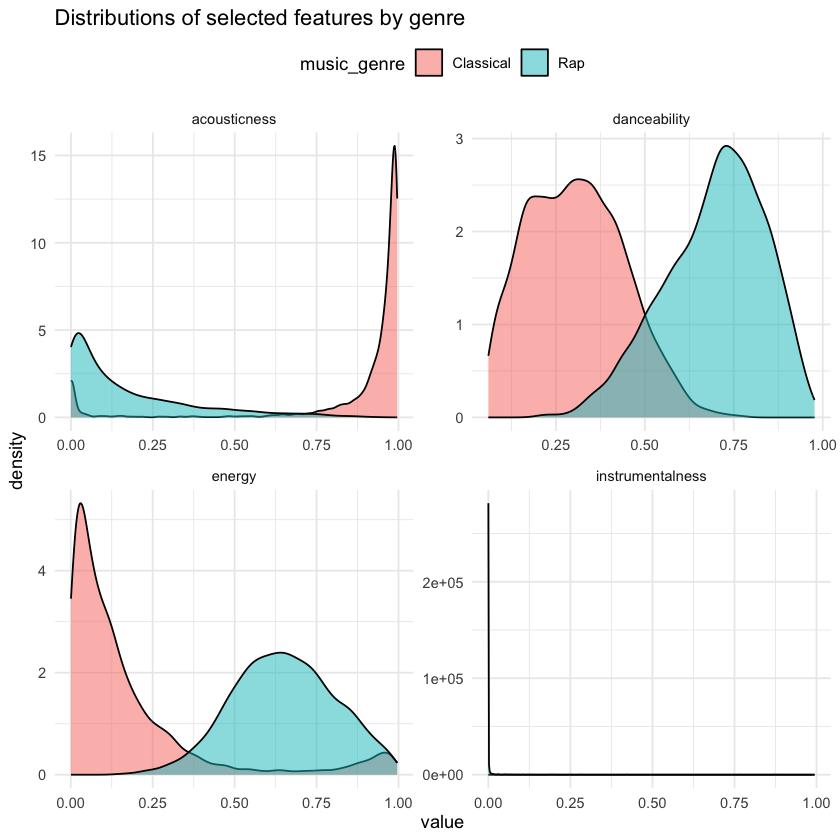

In [4]:
# Select the features we want to plot for analysis in the report
plot_features <- c("danceability", "acousticness", "energy", "instrumentalness")

# Create the plot
p_selected <- df2_clean %>%
  select(all_of(plot_features), music_genre) %>%
  pivot_longer(-music_genre) %>%
  ggplot(aes(x = value, fill = music_genre)) +
  geom_density(alpha = 0.5) +
  facet_wrap(~name, scales = "free") +
  theme_minimal() +
  labs(title = "Distributions of selected features by genre") +
  theme(legend.position = "top")

# Display the plot
print(p_selected)

# Save the plot (Kaggle working directory)
ggsave("/kaggle/working/selected_features_distributions.png", 
       plot = p_selected, width = 12, height = 6, dpi = 300)

## 2. Train/Test Split

In [5]:
set.seed(42)

n <- nrow(df2) # puto não se deveria usar o clean?
train_idx <- sample(1:n, size = floor(0.7 * n))

train_df <- df2[train_idx, ]
test_df  <- df2[-train_idx, ]

cat("Train:", nrow(train_df), "| Test:", nrow(test_df))
table(train_df$music_genre)
table(test_df$music_genre)

Train: 7000 | Test: 3000


Classical       Rap 
     3509      3491 


Classical       Rap 
     1491      1509 

In [6]:
# Define numeric features properly
num_features <- c("popularity", "acousticness", "danceability",
                  "duration_ms", "energy", "instrumentalness",
                  "liveness", "loudness", "speechiness",
                  "tempo", "valence")

# All features
all_features <- c(num_features, "key", "mode")

# Targets
Y_train <- train_df$music_genre
Y_test  <- test_df$music_genre

# --- FIX: force numeric columns ---
X_train_num_raw <- train_df[, num_features, drop = FALSE]
X_test_num_raw  <- test_df[,  num_features, drop = FALSE]

X_train_num_raw[] <- lapply(X_train_num_raw, function(x) as.numeric(as.character(x)))
X_test_num_raw[]  <- lapply(X_test_num_raw,  function(x) as.numeric(as.character(x)))

# Replace any NA created during coercion
X_train_num_raw[is.na(X_train_num_raw)] <- 0.  #puto tu não devias substituir por 0, isso pode enviesar os dados, o ideal era substituir por uma média ou mediana ou até mesmo usar um modelo de imputação mais avançado
X_test_num_raw[is.na(X_test_num_raw)]   <- 0

# Scaling
scale_center <- colMeans(X_train_num_raw)
scale_sd     <- apply(X_train_num_raw, 2, sd)

# Avoid division by zero
scale_sd[scale_sd == 0] <- 1

X_train_scaled <- scale(X_train_num_raw, center = scale_center, scale = scale_sd)
X_test_scaled  <- scale(X_test_num_raw,  center = scale_center, scale = scale_sd)

# Full feature matrices
X_train     <- train_df[, all_features, drop = FALSE]
X_test      <- test_df[,  all_features, drop = FALSE]
X_train_all <- X_train
X_test_all  <- X_test

cat("Feature matrices ready.\n")

Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”


Feature matrices ready.


In [ ]:
# num_features <- c("popularity", "acousticness", "danceability",
#                   "duration_ms", "energy", "instrumentalness",
#                   "liveness", "loudness", "speechiness",
#                   "tempo", "valence")

# all_features <- c(num_features, "key", "mode")

# # Numeric matrices (for PCA, KPCA, PC algorithm)
# X_train_num_raw <- train_df[, num_features]
# X_test_num_raw  <- test_df[,  num_features]

# scale_center <- colMeans(X_train_num_raw)
# scale_sd     <- apply(X_train_num_raw, 2, sd)

# X_train_scaled <- scale(X_train_num_raw, center = scale_center, scale = scale_sd)
# X_test_scaled  <- scale(X_test_num_raw,  center = scale_center, scale = scale_sd)

# # Full feature matrices (for RF and MI)
# X_train     <- train_df[, all_features]
# X_test      <- test_df[,  all_features]
# X_train_all <- X_train
# X_test_all  <- X_test

# Y_train <- train_df$music_genre
# Y_test  <- test_df$music_genre

# cat("Feature matrices ready.\n")

## 3. PCA

   popularity       acousticness       danceability       duration_ms     
 Min.   :-2.3139   Min.   :-1.24694   Min.   :-1.84057   Min.   :-1.4083  
 1st Qu.:-0.6635   1st Qu.:-1.07650   1st Qu.:-0.84799   1st Qu.:-0.4463  
 Median : 0.2133   Median :-0.05755   Median :-0.04725   Median :-0.1202  
 Mean   : 0.0000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000  
 3rd Qu.: 0.7806   3rd Qu.: 1.07434   3rd Qu.: 0.89215   3rd Qu.: 0.2608  
 Max.   : 2.5342   Max.   : 1.13902   Max.   : 1.98378   Max.   :12.2246  
     energy         instrumentalness     liveness          loudness      
 Min.   :-1.34362   Min.   :-0.7653   Min.   :-1.0629   Min.   :-3.4936  
 1st Qu.:-1.02222   1st Qu.:-0.7653   1st Qu.:-0.5639   1st Qu.:-0.8179  
 Median : 0.09502   Median :-0.7642   Median :-0.4022   Median : 0.4284  
 Mean   : 0.00000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.86226   3rd Qu.: 1.3166   3rd Qu.: 0.1494   3rd Qu.: 0.8568  
 Max.   : 1.91578   Max.   : 1.

[1] 11 11

 [1] 38175.210  7247.679  6758.126  6588.469  4911.534  4579.560  2935.197
 [8]  2479.566  1807.908  1031.752   474.001


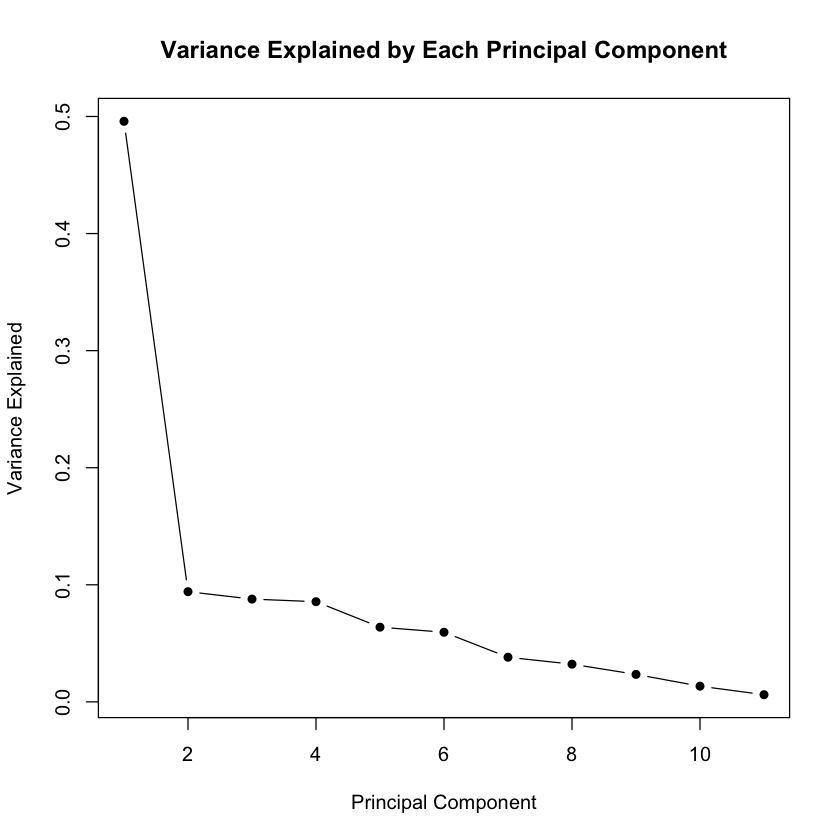

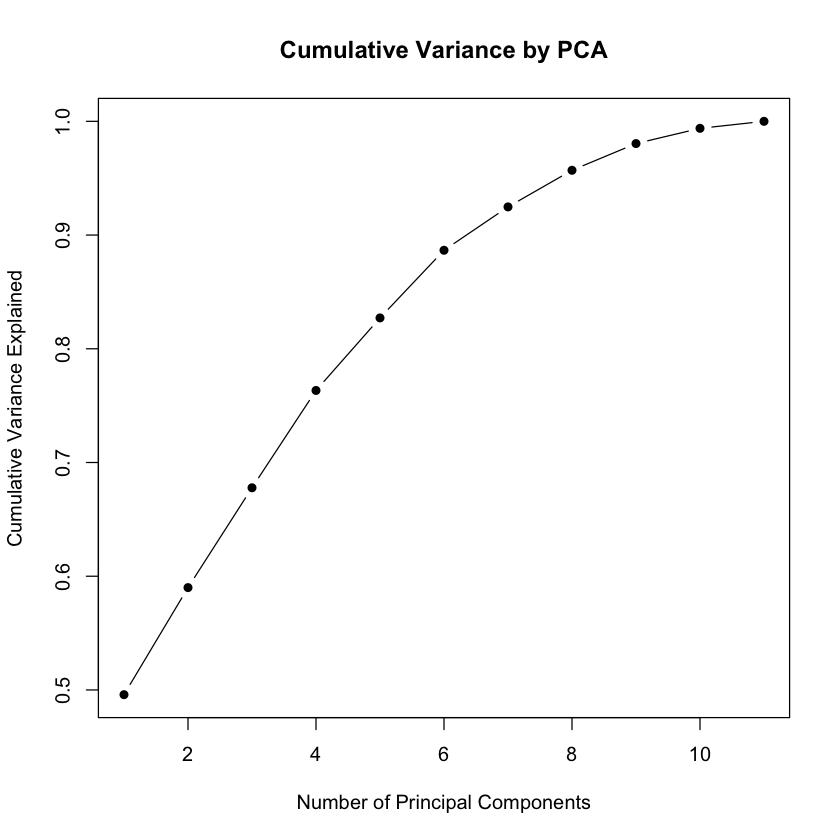

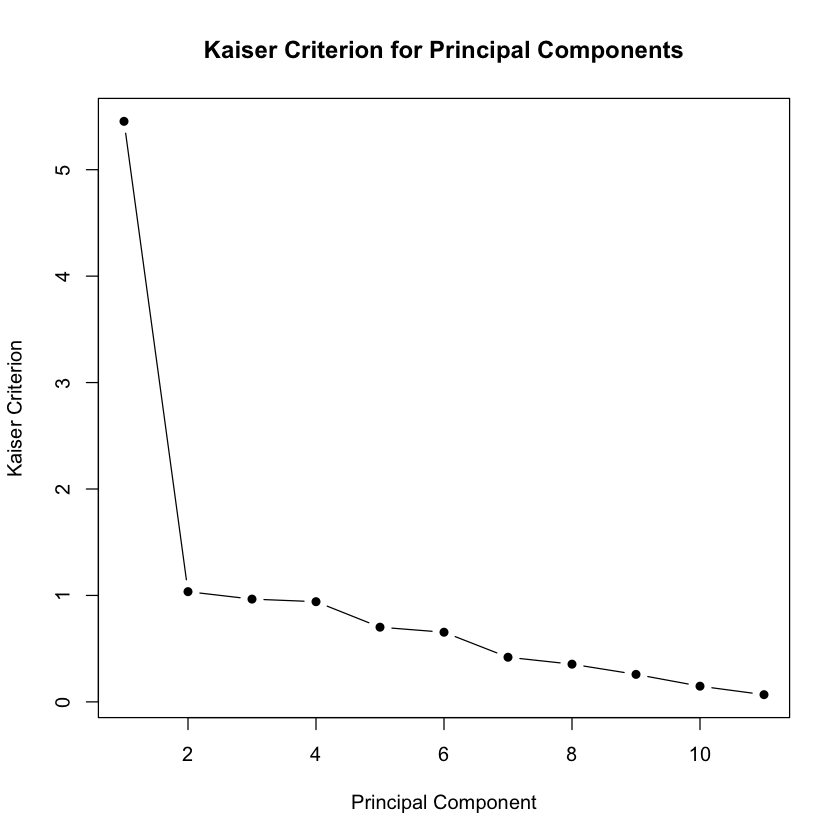

In [15]:
#doing PCA via SVD

#standerdização dos dados através da média e desvio padrão de cada coluna
summary(X_train_scaled)
X_SVD <-  as.matrix(X_train_scaled)


if (nrow(X_SVD) > ncol(X_SVD)) {

    H = t(X_SVD) %*% X_SVD   
    n = nrow(X_SVD)   

} else {

    H = X_SVD %*% t(X_SVD)
    n = ncol(X_SVD)
}

#verificar que H tem as dmenores dimensões possíveis
dim(H)

#decompor H em autovetores e autovalores
eigen_H <- eigen(H)

info_percentage <- eigen_H$values / sum(eigen_H$values)

cum_info_percentage <- cumsum(eigen_H$values) / sum(eigen_H$values)

info_kaiser <- eigen_H$values / (n - 1)

print(eigen_H$values)
plot(info_percentage, type = "b", pch = 16,
     xlab = "Principal Component", ylab = "Variance Explained",
     main = "Variance Explained by Each Principal Component")
plot(cum_info_percentage, type = "b", pch = 16,
     xlab = "Number of Principal Components", ylab = "Cumulative Variance Explained",
     main = "Cumulative Variance by PCA")
plot(info_kaiser, type = "b", pch = 16,
     xlab = "Principal Component", ylab = "Kaiser Criterion",
     main = "Kaiser Criterion for Principal Components")

In [19]:
n = 5

V <- eigen_H$vectors
U <- matrix(0, nrow = nrow(X_SVD), ncol = n)
X_approx <- matrix(0, nrow = nrow(X_SVD), ncol=ncol(X_SVD))

for (i in 1:n) {
  # cálculo de u_i e sucessivamente de X_approximado
  
  U[,i] <- (1/sqrt(eigen_H$values[i])) * X_SVD %*% eigen_H$vectors[,i]
  X_approx <- X_approx + U[,i] %*% t(V[,i]) * sqrt(eigen_H$values[i])
}

summary(X_approx)
E_approx <- X_SVD - X_approx
summary(E_approx)

       V1                V2                V3                V4         
 Min.   :-2.1867   Min.   :-1.4253   Min.   :-2.5179   Min.   :-1.8803  
 1st Qu.:-0.8114   1st Qu.:-0.8799   1st Qu.:-0.8504   1st Qu.:-0.4909  
 Median : 0.2286   Median :-0.4016   Median : 0.1612   Median :-0.1106  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.7708   3rd Qu.: 0.9624   3rd Qu.: 0.7737   3rd Qu.: 0.3123  
 Max.   : 1.4927   Max.   : 1.8939   Max.   : 1.7837   Max.   :11.5158  
       V5                V6                V7                V8         
 Min.   :-1.9191   Min.   :-1.6529   Min.   :-1.3199   Min.   :-1.9323  
 1st Qu.:-0.9571   1st Qu.:-0.7327   1st Qu.:-0.5875   1st Qu.:-0.9512  
 Median : 0.3718   Median :-0.3478   Median :-0.3401   Median : 0.3732  
 Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000   Mean   : 0.0000  
 3rd Qu.: 0.8688   3rd Qu.: 0.8557   3rd Qu.: 0.1927   3rd Qu.: 0.8731  
 Max.   : 1.6069   Max.   : 1.5806   Max.   : 5.349

   popularity        acousticness       danceability       duration_ms      
 Min.   :-2.06218   Min.   :-1.76237   Min.   :-1.89775   Min.   :-1.00423  
 1st Qu.:-0.30882   1st Qu.:-0.22051   1st Qu.:-0.33348   1st Qu.:-0.12276  
 Median : 0.01933   Median :-0.03076   Median : 0.03382   Median :-0.01113  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.36051   3rd Qu.: 0.19471   3rd Qu.: 0.34907   3rd Qu.: 0.11883  
 Max.   : 2.20551   Max.   : 1.42006   Max.   : 1.46152   Max.   : 0.70883  
     energy          instrumentalness      liveness           loudness         
 Min.   :-1.225002   Min.   :-1.93574   Min.   :-0.73126   Min.   :-1.9905673  
 1st Qu.:-0.225974   1st Qu.:-0.20836   1st Qu.:-0.11666   1st Qu.:-0.1775062  
 Median :-0.007876   Median : 0.04555   Median : 0.01412   Median :-0.0007746  
 Mean   : 0.000000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.0000000  
 3rd Qu.: 0.196721   3rd Qu.: 0.35619   3rd Qu.: 0.12731   3r

## 4. Kernel PCA

In [20]:
library(RSpectra)

X_KPCA_sig <- as.matrix(X_train_scaled)


#construir o sigmoid kernel
kappa <- 0.1
c <- 0

K <- tanh(kappa * (X_KPCA_sig %*% t(X_KPCA_sig)) + c)  

dim(K)



#centrar a matriz kernel
n = nrow(K)
one_n <- matrix(1/n, n, n)
dim(one_n)

K_cent <- K - one_n %*% K - K %*% one_n + one_n %*% K %*% one_n

#decompor a matrix centrada em eigenvetores e eigenvalores

K_eigen <- eigs_sym(K_cent, k = 4, opts = list(tol = 1e-2, maxitr = 200))




[1] 7000 7000

[1] 7000 7000

$values
[1] 3205.5217  523.9121  507.2313  452.3308

$vectors
                 [,1]          [,2]          [,3]          [,4]
   [1,]  1.420215e-02 -1.273671e-02  1.576618e-02  1.105875e-02
   [2,] -1.509191e-02  2.350066e-03 -6.531579e-03  9.284866e-03
   [3,] -1.590778e-02  2.747993e-03 -3.788546e-03 -6.926424e-03
   [4,]  1.118467e-02  8.817169e-03  2.535484e-03  7.241747e-04
   [5,] -1.170611e-02 -1.443543e-03 -4.548443e-03 -5.853624e-04
   [6,]  7.438718e-03 -2.022096e-02 -2.506096e-02 -1.584697e-02
   [7,] -1.414282e-02  9.364655e-04  3.445954e-04 -1.018141e-02
   [8,]  1.311380e-02 -3.045404e-03 -4.215260e-03  1.002030e-02
   [9,] -1.342102e-02 -5.183151e-03 -3.414779e-03 -1.454794e-02
  [10,] -1.563393e-02  2.294597e-04 -7.079264e-03 -5.944794e-03
  [11,]  6.936113e-03 -2.206456e-02 -2.232313e-02 -1.818781e-02
  [12,] -1.452056e-02 -4.660634e-03  1.916919e-03  4.762671e-03
  [13,] -1.404891e-02  5.098351e-03  9.063173e-03  1.776581e-03
  [14,]  8.314518e-03  8.371121e-03 -8.957

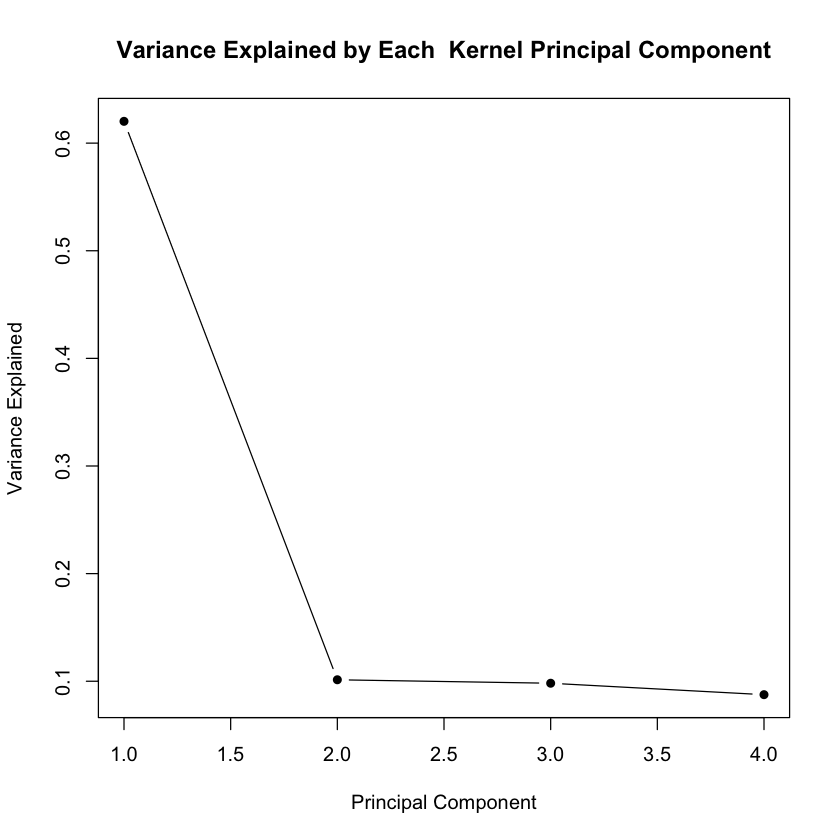

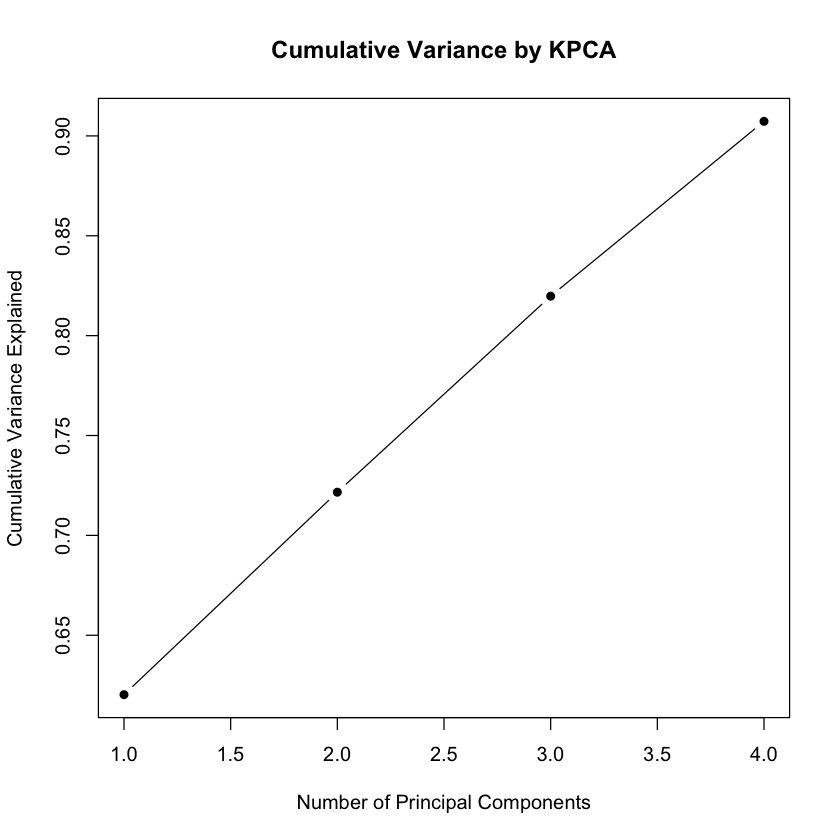

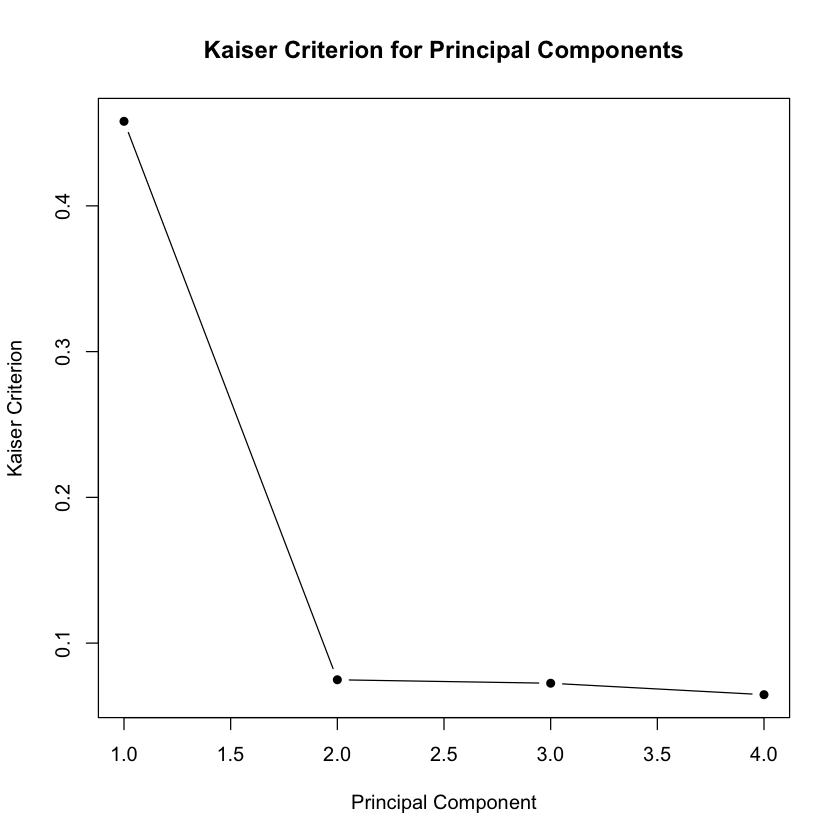

In [ ]:
print(K_eigen)

info_percentageK <- K_eigen$values / sum(diag(K_cent))

cum_info_percentageK <- cumsum(K_eigen$values) / sum(diag(K_cent))
info_kaiserK <- K_eigen$values / (n - 1)

print(K_eigen$values)
plot(info_percentageK, type = "b", pch = 16,
     xlab = "Principal Component", ylab = "Variance Explained",
     main = "Variance Explained by Each  Kernel Principal Component")
plot(cum_info_percentageK, type = "b", pch = 16,
     xlab = "Number of Principal Components", ylab = "Cumulative Variance Explained",
     main = "Cumulative Variance by KPCA")
plot(info_kaiserK, type = "b", pch = 16,
     xlab = "Principal Component", ylab = "Kaiser Criterion",
     main = "Kaiser Criterion for Principal Components")

## 5. Feature Selection

In [ ]:
# 1. Define the numeric features
num_features <- c("popularity", "acousticness", "danceability", "duration_ms",
                  "energy", "instrumentalness", "liveness", "loudness",
                  "speechiness", "valence", "tempo")

# 2. Define the improved function
prep_and_impute <- function(train_df, test_df, features) {
  
  # Helper to clean specific column quirks (Tempo and Duration)
  clean_quirks <- function(df) {
    # Convert tempo to numeric safely
    df$tempo <- suppressWarnings(as.numeric(as.character(df$tempo)))
    # Treat -1 in duration as missing data (NA)
    df$duration_ms[df$duration_ms == -1] <- NA
    return(df)
  }

  # Apply quirk cleaning to raw dataframes first
  train_df <- clean_quirks(train_df)
  test_df  <- clean_quirks(test_df)
  
  # Subset columns
  X_train <- train_df[, features, drop = FALSE]
  X_test  <- test_df[, features, drop = FALSE]
  
  # Calculate medians from TRAINING data ONLY
  train_medians <- sapply(X_train, median, na.rm = TRUE)
  
  # Helper to apply the pre-calculated medians
  apply_fix <- function(df, medians) {
    for (col in names(medians)) {
      df[is.na(df[[col]]), col] <- medians[col]
    }
    return(df)
  }
  
  # Apply the training medians to both sets
  X_train_clean <- apply_fix(X_train, train_medians)
  X_test_clean  <- apply_fix(X_test, train_medians)
  
  return(list(train = X_train_clean, test = X_test_clean))
}

# 3. Run the process
processed_data <- prep_and_impute(train_df, test_df, num_features)

# 4. Extract your final dataframes
X_train <- processed_data$train
X_test  <- processed_data$test

# 5. Extract Class vectors
Y_train <- train_df$music_genre
Y_test  <- test_df$music_genre

# 6. Check results
cat("Feature matrix dimensions:", nrow(X_train), "x", ncol(X_train), "\n")
cat("Class distribution:\n"); print(table(Y_train))

In [ ]:
# infotheo::discretize uses equal-frequency binning by default, so that mutual
#information calculation is stable and we get non zero probabilities (which would 
# occur in the continuous case)
# Number of bins ~ sqrt(n), as recommended in the literature
n_bins <- ceiling(sqrt(nrow(X_train)))
cat("Using", n_bins, "bins for discretisation\n")

X_disc <- infotheo::discretize(X_train, disc = "equalfreq", nbins = n_bins)
Y_disc <- as.integer(Y_train)   #alphabetical order assigned to the genres that 
#become integers

In [ ]:
# STEP 1 — MI(Xi ; C) for every feature (relevance)
mi_feature_class <- sapply(seq_len(ncol(X_disc)), function(i)
  infotheo::mutinformation(X_disc[, i], Y_disc))
names(mi_feature_class) <- colnames(X_disc)

# STEP 2 — MI(Xi ; Xj) for every pair (redundancy matrix)
p     <- ncol(X_disc)
mi_ff <- matrix(0, p, p, dimnames = list(colnames(X_disc), colnames(X_disc)))
for (i in seq_len(p))
  for (j in seq_len(p))
    if (i != j)
      mi_ff[i, j] <- infotheo::mutinformation(X_disc[, i], X_disc[, j])

# STEP 3 — MI(Xi ; Xj | C) for every pair (complementarity matrix)
mi_ff_given_c <- matrix(0, p, p, dimnames = list(colnames(X_disc), colnames(X_disc)))
for (i in seq_len(p)) {
  for (j in seq_len(p)) {
    if (i != j) {
      H_Xi_given_C   <- infotheo::condentropy(X_disc[, i], as.data.frame(Y_disc))
      H_Xi_given_XjC <- infotheo::condentropy(X_disc[, i],
                           data.frame(X_disc[, j], Y_disc))
      mi_ff_given_c[i, j] <- H_Xi_given_C - H_Xi_given_XjC
    }
  }
}

cat("MI tables computed.\n")
cat("MI(popularity, class):", round(mi_feature_class["popularity"], 4), "\n")

In [ ]:
# maxMIFS: OF(Xi) = MI(C; Xi) - max_{Xs in S} MI(Xi, Xs)

run_maxMIFS <- function(mi_fc, mi_ff_mat, k) {
  p        <- length(mi_fc)
  feat_names <- names(mi_fc)
  selected <- integer(0)
  remaining <- seq_len(p)
  scores_log <- list()

  for (step in seq_len(k)) {
    scores <- sapply(remaining, function(i) {
      rel <- mi_fc[i]
      if (length(selected) == 0) return(rel)
      red <- max(mi_ff_mat[i, selected])
      rel - red
    })
    names(scores) <- feat_names[remaining]
    best <- remaining[which.max(scores)]
    selected  <- c(selected, best)
    remaining <- setdiff(remaining, best)
    scores_log[[step]] <- sort(scores, decreasing = TRUE)
  }
  list(selected = feat_names[selected], scores = scores_log)
}

k_select <- ncol(X_disc)   # rank all features

result_maxMIFS <- run_maxMIFS(mi_feature_class, mi_ff, k = k_select)
cat("maxMIFS ranking:\n")
print(result_maxMIFS$selected)

In [ ]:
# DMIM: OF(Xi) = MI(C; Xi) - max_{Xs in S} MI(Xi, Xs) 
# + max_{Xs in S} MI(Xi, Xs | C)


run_DMIM <- function(mi_fc, mi_ff_mat, mi_ff_c_mat, k) {
  p          <- length(mi_fc)
  feat_names <- names(mi_fc)
  selected   <- integer(0)
  remaining  <- seq_len(p)
  scores_log <- list()

  for (step in seq_len(k)) {
    scores <- sapply(remaining, function(i) {
      rel <- mi_fc[i]
      if (length(selected) == 0) return(rel)
      inter_red  <- max(mi_ff_mat[i, selected])          # max MI(Xi, Xs)
      class_red  <- max(mi_ff_c_mat[i, selected])        # max MI(Xi, Xs | C)
      rel - inter_red + class_red
    })
    names(scores) <- feat_names[remaining]
    best      <- remaining[which.max(scores)]
    selected  <- c(selected, best)
    remaining <- setdiff(remaining, best)
    scores_log[[step]] <- sort(scores, decreasing = TRUE)
  }
  list(selected = feat_names[selected], scores = scores_log)
}

result_DMIM <- run_DMIM(mi_feature_class, mi_ff, mi_ff_given_c, k = k_select)
cat("DMIM ranking:\n")
print(result_DMIM$selected)

In [ ]:
# ── Manual MIFS implementation ────────────────────────────────────────────────
# OF(Xi) = MI(C; Xi) - beta * sum_{Xs in S} MI(Xi, Xs)
# Reference: Battiti (1994), beta = 1
run_MIFS <- function(mi_fc, mi_ff_mat, k, beta = 1) {
  p          <- length(mi_fc)
  feat_names <- names(mi_fc)
  selected   <- integer(0)
  remaining  <- seq_len(p)
  scores_log <- list()
  for (step in seq_len(k)) {
    scores <- sapply(remaining, function(i) {
      rel <- mi_fc[i]
      if (length(selected) == 0) return(rel)
      red <- beta * sum(mi_ff_mat[i, selected])     # sum MI(Xi, Xs)
      rel - red
    })
    names(scores) <- feat_names[remaining]
    best      <- remaining[which.max(scores)]
    selected  <- c(selected, best)
    remaining <- setdiff(remaining, best)
    scores_log[[step]] <- sort(scores, decreasing = TRUE)
  }
  list(selected = feat_names[selected], scores = scores_log)
}

result_MIFS <- run_MIFS(mi_feature_class, mi_ff, k = k_select)
cat("MIFS ranking:\n")
print(result_MIFS$selected)

In [ ]:
k_select <- ncol(X_train)

# praznik available methods
result_MIM   <- praznik::MIM(  X_train, Y_train, k = k_select)
result_mRMR  <- praznik::MRMR( X_train, Y_train, k = k_select)
result_CMIM  <- praznik::CMIM( X_train, Y_train, k = k_select)
result_JMI   <- praznik::JMI(  X_train, Y_train, k = k_select)
result_DISR  <- praznik::DISR( X_train, Y_train, k = k_select)  # replaces CIFE


# Manual implementations (using infotheo MI tables)
result_MIFS    <- run_MIFS(   mi_feature_class, mi_ff,                  k = k_select)
result_maxMIFS <- run_maxMIFS(mi_feature_class, mi_ff,                  k = k_select)
result_DMIM    <- run_DMIM(   mi_feature_class, mi_ff, mi_ff_given_c,   k = k_select)

cat("MIM    ranking:", result_MIM$selection,    "\n")
cat("MIFS   ranking:", result_MIFS$selected,    "\n")
cat("mRMR   ranking:", result_mRMR$selection,   "\n")
cat("maxMIFS ranking:", result_maxMIFS$selected, "\n")
cat("DISR   ranking:", result_DISR$selection,   "\n")
cat("CMIM   ranking:", result_CMIM$selection,   "\n")
cat("JMI    ranking:", result_JMI$selection,    "\n")
cat("DMIM   ranking:", result_DMIM$selected,    "\n")

In [ ]:
all_rankings <- data.frame(
  Rank    = seq_len(k_select),
  MIM     = result_MIM$selection,
  MIFS    = result_MIFS$selected,     # manual → $selected
  mRMR    = result_mRMR$selection,
  maxMIFS = result_maxMIFS$selected,  # manual → $selected
  DISR    = result_DISR$selection,    # replaces CIFE
  CMIM    = result_CMIM$selection,
  JMI     = result_JMI$selection,
  DMIM    = result_DMIM$selected      # manual → $selected
)
print(all_rankings)

In [ ]:
# MI(feature, class) as a baseline relevance chart
mi_df <- data.frame(
  Feature = names(mi_feature_class),
  MI      = mi_feature_class
) %>% arrange(desc(MI))

ggplot(mi_df, aes(x = reorder(Feature, MI), y = MI, fill = MI)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#b3cde3", high = "#084594") +
  labs(title = "MIM scores – MI(Feature, Class)",
       x = "Feature", y = "Mutual Information (nats)") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

In [ ]:
# Choose a cutoff k 
k_final <- 6   # adjust based on your analysis

methods <- c("MIM","MIFS","mRMR","maxMIFS","DISR","CMIM","JMI","DMIM")
top_k_list <- list(
  MIM     = result_MIM$selection[1:k_final],
  MIFS    = result_MIFS$selected[1:k_final],     # manual → $selected
  mRMR    = result_mRMR$selection[1:k_final],
  maxMIFS = result_maxMIFS$selected[1:k_final],  # manual → $selected
  DISR    = result_DISR$selection[1:k_final],    # replaces CIFE
  CMIM    = result_CMIM$selection[1:k_final],
  JMI     = result_JMI$selection[1:k_final],
  DMIM    = result_DMIM$selected[1:k_final]      # manual → $selected
)

all_feats <- unique(unlist(top_k_list))
heat_mat  <- sapply(top_k_list, function(sel) as.integer(all_feats %in% sel))
rownames(heat_mat) <- all_feats

heat_df <- as.data.frame(heat_mat) %>%
  tibble::rownames_to_column("Feature") %>%
  pivot_longer(-Feature, names_to = "Method", values_to = "Selected")

ggplot(heat_df, aes(x = Method, y = Feature, fill = factor(Selected))) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_manual(values = c("0" = "#f0f0f0", "1" = "#2171b5"),
                    labels = c("Not selected", "Selected"),
                    name = "") +
  labs(title = paste0("Top-", k_final, " features selected by each method"),
       x = "", y = "") +
  theme_minimal(base_size = 13) +
  theme(axis.text.x = element_text(angle = 35, hjust = 1))

In [ ]:
# Final selected feature sets (top-k_final features per method)
selected_features <- lapply(top_k_list, function(s) s)

cat("Selected features per method (k =", k_final, "):\n")
for (m in names(selected_features)) {
  cat(sprintf("  %-8s: %s\n", m, paste(selected_features[[m]], collapse = ", ")))
}

# Build reduced train/test sets for each method (used in Q6)
train_reduced <- lapply(selected_features, function(feats) train_df[, feats, drop = FALSE])
test_reduced  <- lapply(selected_features, function(feats) test_df[,  feats, drop = FALSE])

## 6. Classification

### 6.1 Evaluation metrics definitions

In [ ]:
# Returns Accuracy, Macro Recall, Macro Precision, Macro F1

compute_metrics <- function(true_labels, predicted_labels) {
  
  classes <- levels(true_labels)
  cm      <- table(Predicted = predicted_labels, Actual = true_labels)
  
  # Per-class recall and precision
  recall    <- sapply(classes, function(c)
    cm[c, c] / sum(cm[, c]))           # TP / (TP + FN)
  
  precision <- sapply(classes, function(c)
    cm[c, c] / sum(cm[c, ]))           # TP / (TP + FP)
  
  # Handle division by zero setting metrics to zero
  recall[is.nan(recall)]       <- 0
  precision[is.nan(precision)] <- 0
  
  f1 <- 2 * recall * precision / (recall + precision)
  f1[is.nan(f1)] <- 0
  
  # Macro averages
  macro_recall    <- mean(recall)
  macro_precision <- mean(precision)
  macro_f1        <- mean(f1)
  
  # Overall accuracy
  accuracy <- sum(diag(cm)) / sum(cm)
  
  list(
    Accuracy         = round(accuracy,         4),
    Macro_Recall     = round(macro_recall,     4),
    Macro_Precision  = round(macro_precision,  4),
    Macro_F1         = round(macro_f1,         4),
    Confusion_Matrix = cm
  )
}

### 6.2 Random Forest Model

#### 6.2.1 Training on Original Data Set

In [ ]:
# get importance scores
imp_df <- as.data.frame(importance(rf_original))
imp_df$Feature <- rownames(imp_df)

# MeanDecreaseAccuracy is the permutation-based importance
imp_df <- imp_df %>% arrange(desc(MeanDecreaseAccuracy))

ggplot(imp_df, aes(x = reorder(Feature, MeanDecreaseAccuracy),
                   y = MeanDecreaseAccuracy,
                   fill = MeanDecreaseAccuracy)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  scale_fill_gradient(low = "#c6dbef", high = "#08519c") +
  labs(title    = "Random Forest — Variable Importance (Full Dataset)",
       subtitle = "Mean Decrease in Accuracy (permutation-based)",
       x = "Feature", y = "Mean Decrease Accuracy") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "none")

In [ ]:
set.seed(42)

rf_original <- randomForest(
  x          = X_train_all,
  y          = Y_train,
  ntree      = 500,
  mtry       = floor(sqrt(ncol(X_train_all))),
  nodesize   = 1,
  importance = TRUE
)

# Predict on the test set
pred_original <- predict(rf_original, newdata = X_test_all)

# Evaluate
metrics_original <- compute_metrics(Y_test, pred_original)

cat("RF: Original Dataset\n")
cat("Accuracy        :", metrics_original$Accuracy,        "\n")
cat("Macro Recall    :", metrics_original$Macro_Recall,    "\n")
cat("Macro Precision :", metrics_original$Macro_Precision, "\n")
cat("Macro F1        :", metrics_original$Macro_F1,        "\n")
cat("\nConfusion Matrix:\n")
print(metrics_original$Confusion_Matrix)

# OOB error estimate (free internal validation)
cat("\nOOB Error Estimate:", round(rf_original$err.rate[500, "OOB"], 4), "\n")

#### 6.2.2 Training on PCA derived data

In [ ]:
# ── Assumes pca_train and pca_test exist from Exercise 3 ─────────────────────
# These should be data frames of PCA scores with n_pca_components columns
# e.g. produced by:
#   pca_model  <- prcomp(X_train_num, center = TRUE, scale. = TRUE)
#   pca_train  <- as.data.frame(pca_model$x[, 1:n_pca])
#   pca_test   <- as.data.frame(predict(pca_model, X_test_num)[, 1:n_pca])

set.seed(42)

rf_pca <- randomForest(
  x        = pca_train,
  y        = Y_train,
  ntree    = 500,
  mtry     = floor(sqrt(ncol(pca_train))),
  nodesize = 1
)

pred_pca     <- predict(rf_pca, newdata = pca_test)
metrics_pca  <- compute_metrics(Y_test, pred_pca)

cat("=== RF — PCA Reduced ===\n")
cat("Components used :", ncol(pca_train), "\n")
cat("Accuracy        :", metrics_pca$Accuracy,        "\n")
cat("Macro Recall    :", metrics_pca$Macro_Recall,    "\n")
cat("Macro Precision :", metrics_pca$Macro_Precision, "\n")
cat("Macro F1        :", metrics_pca$Macro_F1,        "\n")

#### 6.2.3 Training on Kernel-PCA derived data

In [ ]:
# ── Assumes kpca_train and kpca_test exist from Exercise 4 ───────────────────
# e.g. produced via kernlab::kpca or similar

set.seed(42)

rf_kpca <- randomForest(
  x        = kpca_train,
  y        = Y_train,
  ntree    = 500,
  mtry     = floor(sqrt(ncol(kpca_train))),
  nodesize = 1
)

pred_kpca    <- predict(rf_kpca, newdata = kpca_test)
metrics_kpca <- compute_metrics(Y_test, pred_kpca)

cat("=== RF — Kernel PCA Reduced ===\n")
cat("Components used :", ncol(kpca_train), "\n")
cat("Accuracy        :", metrics_kpca$Accuracy,        "\n")
cat("Macro Recall    :", metrics_kpca$Macro_Recall,    "\n")
cat("Macro Precision :", metrics_kpca$Macro_Precision, "\n")
cat("Macro F1        :", metrics_kpca$Macro_F1,        "\n")

#### 6.2.4 Training on information-theoretic selected features

In [ ]:
# ── Assumes selected_features list exists from Exercise 5 ────────────────────
# selected_features$MIM, $MIFS, $mRMR, $maxMIFS, $CIFE, $CMIM, $JMI, $DMIM
# Each is a character vector of feature names

set.seed(42)

rf_fs_models  <- list()
rf_fs_metrics <- list()

for (method in names(selected_features)) {
  
  feats <- selected_features[[method]]
  
  # Build feature matrices for this subset
  X_tr <- train_df[, feats, drop = FALSE]
  X_te <- test_df[,  feats, drop = FALSE]
  
  # Ensure factors have consistent levels
  for (f in feats) {
    if (is.factor(train_df[[f]])) {
      X_tr[[f]] <- factor(X_tr[[f]])
      X_te[[f]] <- factor(X_te[[f]], levels = levels(X_tr[[f]]))
    }
  }
  
  # Train
  rf_fit <- randomForest(
    x        = X_tr,
    y        = Y_train,
    ntree    = 500,
    mtry     = max(1, floor(sqrt(length(feats)))),
    nodesize = 1
  )
  
  # Predict and evaluate
  preds   <- predict(rf_fit, newdata = X_te)
  metrics <- compute_metrics(Y_test, preds)
  
  rf_fs_models[[method]]  <- rf_fit
  rf_fs_metrics[[method]] <- metrics
  
  cat(sprintf("%-10s | Acc: %.4f | MacroRe: %.4f | MacroPr: %.4f | MacroF1: %.4f\n",
              method,
              metrics$Accuracy,
              metrics$Macro_Recall,
              metrics$Macro_Precision,
              metrics$Macro_F1))
}

#### 6.2.5 analysis and visualizations

In [ ]:
# Build results data frame covering all strategies
all_results <- bind_rows(
  
  # Original dataset
  data.frame(
    Strategy = "Original",
    Method   = "—",
    Accuracy = metrics_original$Accuracy,
    MacroRecall    = metrics_original$Macro_Recall,
    MacroPrecision = metrics_original$Macro_Precision,
    MacroF1        = metrics_original$Macro_F1
  ),
  
  # PCA
  data.frame(
    Strategy = "PCA",
    Method   = paste0(ncol(pca_train), " components"),
    Accuracy = metrics_pca$Accuracy,
    MacroRecall    = metrics_pca$Macro_Recall,
    MacroPrecision = metrics_pca$Macro_Precision,
    MacroF1        = metrics_pca$Macro_F1
  ),
  
  # Kernel PCA
  data.frame(
    Strategy = "KernelPCA",
    Method   = paste0(ncol(kpca_train), " components"),
    Accuracy = metrics_kpca$Accuracy,
    MacroRecall    = metrics_kpca$Macro_Recall,
    MacroPrecision = metrics_kpca$Macro_Precision,
    MacroF1        = metrics_kpca$Macro_F1
  ),
  
  # Feature selection methods
  bind_rows(lapply(names(rf_fs_metrics), function(m) {
    met <- rf_fs_metrics[[m]]
    data.frame(
      Strategy       = "FeatureSelection",
      Method         = m,
      Accuracy       = met$Accuracy,
      MacroRecall    = met$Macro_Recall,
      MacroPrecision = met$Macro_Precision,
      MacroF1        = met$Macro_F1
    )
  }))
)

# Print clean table
cat("\n========== RF RESULTS SUMMARY ==========\n")
print(all_results %>% arrange(desc(MacroF1)), row.names = FALSE)

In [ ]:
# ── Bar chart: Macro F1 across all strategies ─────────────────────────────────
plot_df <- all_results %>%
  mutate(Label = ifelse(Strategy == "FeatureSelection",
                        paste0("FS-", Method),
                        paste0(Strategy,
                               ifelse(Method == "—", "", paste0("\n(", Method, ")")))))

ggplot(plot_df, aes(x = reorder(Label, MacroF1),
                    y = MacroF1,
                    fill = Strategy)) +
  geom_bar(stat = "identity", width = 0.7) +
  geom_text(aes(label = round(MacroF1, 3)),
            hjust = -0.1, size = 3.5) +
  coord_flip(ylim = c(min(plot_df$MacroF1) - 0.05, 1.02)) +
  scale_fill_manual(values = c(
    "Original"         = "#2171b5",
    "PCA"              = "#6baed6",
    "KernelPCA"        = "#bdd7e7",
    "FeatureSelection" = "#238b45"
  )) +
  labs(title    = "Random Forest — Macro F1 by Dimensionality Reduction Strategy",
       subtitle = "Higher is better",
       x = "", y = "Macro F1") +
  theme_minimal(base_size = 13) +
  theme(legend.position = "bottom")

In [ ]:
# Reshape to long format for faceted plot
fs_results <- all_results %>%
  filter(Strategy == "FeatureSelection") %>%
  select(Method, Accuracy, MacroRecall, MacroPrecision, MacroF1) %>%
  pivot_longer(cols = -Method,
               names_to  = "Metric",
               values_to = "Value")

ggplot(fs_results, aes(x = reorder(Method, Value),
                       y = Value,
                       fill = Method)) +
  geom_bar(stat = "identity") +
  facet_wrap(~ Metric, scales = "free_y", ncol = 2) +
  coord_flip() +
  scale_fill_brewer(palette = "Dark2") +
  labs(title = "RF Performance by Feature Selection Method",
       x = "", y = "Score") +
  theme_minimal(base_size = 12) +
  theme(legend.position = "none",
        strip.text      = element_text(face = "bold"))

In [ ]:
# Identify best and worst by Macro F1
fs_f1 <- sapply(rf_fs_metrics, function(m) m$Macro_F1)
best_method  <- names(which.max(fs_f1))
worst_method <- names(which.min(fs_f1))

cat("Best  method by Macro F1:", best_method,  
    "-", round(fs_f1[best_method],  4), "\n")
cat("Worst method by Macro F1:", worst_method, 
    "-", round(fs_f1[worst_method], 4), "\n")

# Plot confusion matrices side by side
par(mfrow = c(1, 2))

fourfoldplot(rf_fs_metrics[[best_method]]$Confusion_Matrix,
             color  = c("#238b45", "#cb181d"),
             conf.level = 0,
             margin = 1,
             main   = paste("Best:", best_method))

fourfoldplot(rf_fs_metrics[[worst_method]]$Confusion_Matrix,
             color  = c("#238b45", "#cb181d"),
             conf.level = 0,
             margin = 1,
             main   = paste("Worst:", worst_method))

par(mfrow = c(1, 1))

In [1]:
#Comparing RF variable importance with MI rankings

# RF importance from the full model
rf_imp <- importance(rf_original)[, "MeanDecreaseAccuracy"]
rf_imp_df <- data.frame(
  Feature    = names(rf_imp),
  RF_Rank    = rank(-rf_imp),
  RF_Importance = rf_imp
)

# MI ranking from MIM (simplest benchmark — pure MI score)
# Assumes mi_feature_class exists from Exercise 5 cells
mi_df <- data.frame(
  Feature  = names(mi_feature_class),
  MIM_Rank = rank(-mi_feature_class)
) %>% filter(Feature %in% num_features)

# Merge and display
comparison_df <- merge(rf_imp_df, mi_df, by = "Feature") %>%
  arrange(RF_Rank)

cat("=== RF Importance Rank vs MIM Rank ===\n")
print(comparison_df[, c("Feature", "RF_Rank", "MIM_Rank")],
      row.names = FALSE)

# Rank correlation
cat("\nSpearman correlation between RF rank and MIM rank:",
    round(cor(comparison_df$RF_Rank,
              comparison_df$MIM_Rank,
              method = "spearman"), 3), "\n")

ERROR: Error in importance(rf_original): could not find function "importance"


### 6.3 KNN

#### 6.3.1 Training on Original Data Set

#### 6.3.2 Training on PCA derived data

#### 6.3.3 Training on Kernel-PCA derived data

#### 6.3.4 Training on information-theoretic reduced data

## 7. Causal Discovery

### 7.1 DAG

In [ ]:
install.packages("pcalg")
library(pcalg)

# Use only the numeric features on training data
# PC algorithm needs a correlation/conditional independence test
# For continuous features use gaussCItest

suffStat <- list(C = cor(X_train_scaled), n = nrow(X_train_scaled))

pc_fit <- pc(
  suffStat  = suffStat,
  indepTest = gaussCItest,
  alpha     = 0.01,        # significance level for CI tests
  labels    = colnames(X_train_scaled),
  verbose   = FALSE
)

plot(pc_fit, main = "PC Algorithm — Estimated CPDAG")

### 7.2 Do calculus

In [ ]:
# Suppose the graph reveals that 'energy' confounds both 
# 'loudness' and 'danceability'. Backdoor adjustment:

# p(genre | do(speechiness = t)) = 
#   sum_z p(genre | speechiness=t, Z=z) * p(Z=z)
# where Z is the backdoor adjustment set

# Discretise speechiness into bins for estimation
speechiness_bins <- quantile(X_train$speechiness, 
                              probs = seq(0, 1, by = 0.1))

# For each bin value of speechiness, compute adjusted prediction
library(dplyr)

adjustment_set <- c("energy", "acousticness")  # from PC graph

do_predictions <- lapply(1:(length(speechiness_bins)-1), function(b) {
  
  lo <- speechiness_bins[b]; hi <- speechiness_bins[b+1]
  
  # Marginalise over adjustment set Z
  # For each unique combo of Z values, get classifier prediction
  # weighted by p(Z)
  
  X_intervened <- X_train
  X_intervened$speechiness <- (lo + hi) / 2  # set by intervention
  
  # Adjusted prediction: weight by marginal p(Z), not p(Z|speechiness)
  probs <- predict(rf_original, newdata = X_intervened, type = "prob")
  
  # Return weighted average
  data.frame(
    speechiness_val = (lo + hi) / 2,
    p_rap           = mean(probs[, "Rap"]),
    p_classical     = mean(probs[, "Classical"])
  )
})

do_curve <- bind_rows(do_predictions)

### 7.3 Robustness Scores

In [ ]:
# For a fixed value of the "relevant" feature (e.g. speechiness high -> Rap)
# intervene on each "nuisance" feature and measure shift in classifier output

compute_IRS_proxy <- function(model, X_data, relevant_feat, 
                               nuisance_feats, n_grid = 10) {
  
  # Fix relevant feature at its median
  X_fixed <- X_data
  X_fixed[[relevant_feat]] <- median(X_data[[relevant_feat]])
  
  baseline_pred <- mean(predict(model, X_fixed, type = "prob")[, "Rap"])
  
  pida_per_nuisance <- sapply(nuisance_feats, function(nf) {
    
    grid_vals <- quantile(X_data[[nf]], probs = seq(0.05, 0.95, length=n_grid))
    
    shifted_preds <- sapply(grid_vals, function(v) {
      X_shifted <- X_fixed
      X_shifted[[nf]] <- v
      mean(predict(model, X_shifted, type = "prob")[, "Rap"])
    })
    
    max(abs(shifted_preds - baseline_pred))  # MPIDA analog
  })
  
  # IRS analog: 1 - (mean PIDA / normaliser)
  normaliser <- sd(predict(model, X_data, type="prob")[,"Rap"])
  1 - mean(pida_per_nuisance) / (normaliser + 1e-8)
}

# Compute for each method's selected feature subset
irs_scores <- sapply(names(selected_features), function(method) {
  feats <- selected_features[[method]]
  relevant <- feats[1]       # top-ranked feature
  nuisance <- feats[-1]      # remaining selected features
  compute_IRS_proxy(rf_original, X_train[, feats], relevant, nuisance)
})

print(round(sort(irs_scores, decreasing=TRUE), 3))